# 💳 Credit Card Fraud Detection
## End-to-End ML Pipeline: EDA → Preprocessing → Training → Evaluation

**Dataset:** 284,807 transactions | 492 frauds (0.17%) | 28 PCA features + Time + Amount

**Challenge:** Extreme class imbalance — this notebook covers the best strategies to handle it.

---
## 📦 1. Install & Import Libraries

In [1]:
# Install required packages (run once)
!%pip install imbalanced-learn xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn --quiet

'%pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Sampling
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, precision_score, recall_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 2. Load Dataset

In [3]:
# ⚠️ Update path if running locally
df = pd.read_csv(r'C:\Users\vaishnavi\OneDrive\Desktop\ML\Credit Card Fraud Detection\data\creditcard.csv')

print(f"📐 Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")
df.head()

📐 Shape: (284807, 31)
📋 Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 🔍 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Transactions : {len(df):,}")
print(f"Total Features     : {df.shape[1] - 1}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print()

# Class distribution
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]
print("CLASS DISTRIBUTION")
print(f"  Legitimate (0): {len(legit):,}  ({len(legit)/len(df)*100:.2f}%)")
print(f"  Fraud      (1): {len(fraud):,}   ({len(fraud)/len(df)*100:.4f}%)")
print(f"  Imbalance Ratio: {len(legit)//len(fraud)}:1")

DATASET OVERVIEW
Total Transactions : 284,807
Total Features     : 30
Missing Values     : 0
Duplicate Rows     : 1081

CLASS DISTRIBUTION
  Legitimate (0): 284,315  (99.83%)
  Fraud      (1): 492   (0.1727%)
  Imbalance Ratio: 577:1


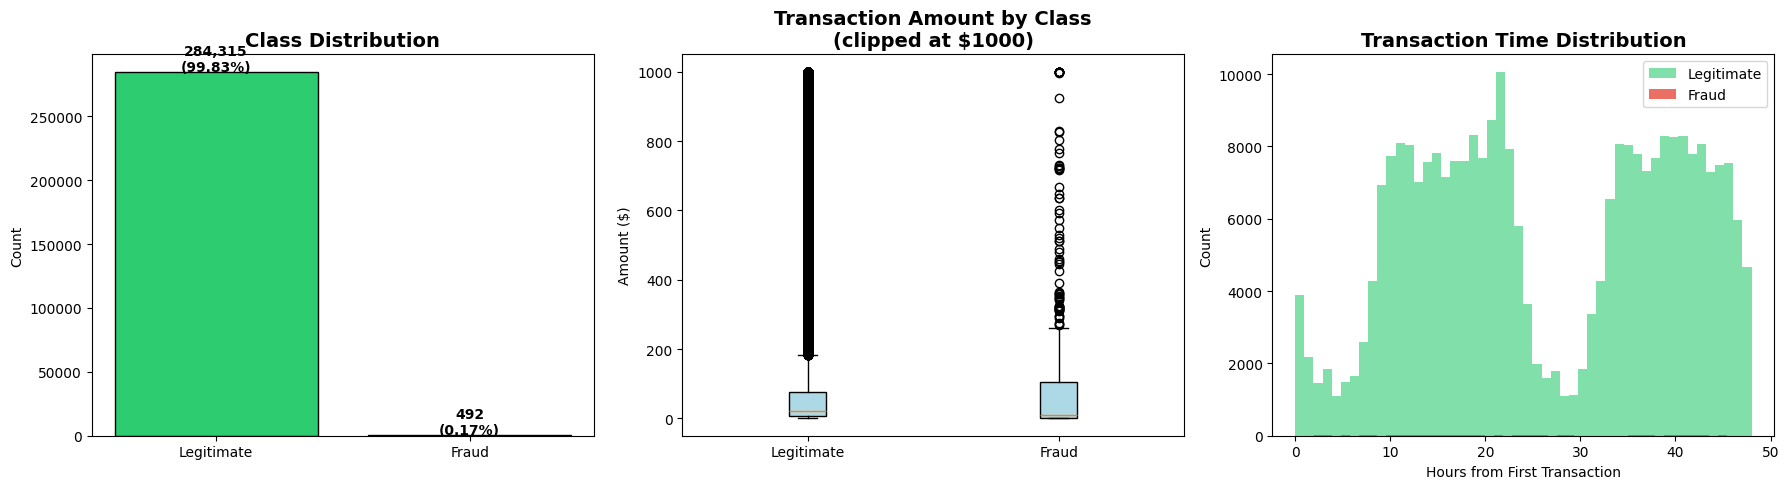

📊 EDA Overview plot saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Class imbalance
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.2f}%)', ha='center', fontweight='bold')

# Plot 2: Transaction Amount by class
axes[1].boxplot(
    [legit['Amount'].clip(upper=1000), fraud['Amount'].clip(upper=1000)],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Transaction Amount by Class\n(clipped at $1000)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amount ($)')

# Plot 3: Time distribution
axes[2].hist(legit['Time'] / 3600, bins=50, alpha=0.6, label='Legitimate', color='#2ecc71')
axes[2].hist(fraud['Time'] / 3600, bins=50, alpha=0.8, label='Fraud', color='#e74c3c')
axes[2].set_title('Transaction Time Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Hours from First Transaction')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 EDA Overview plot saved.")

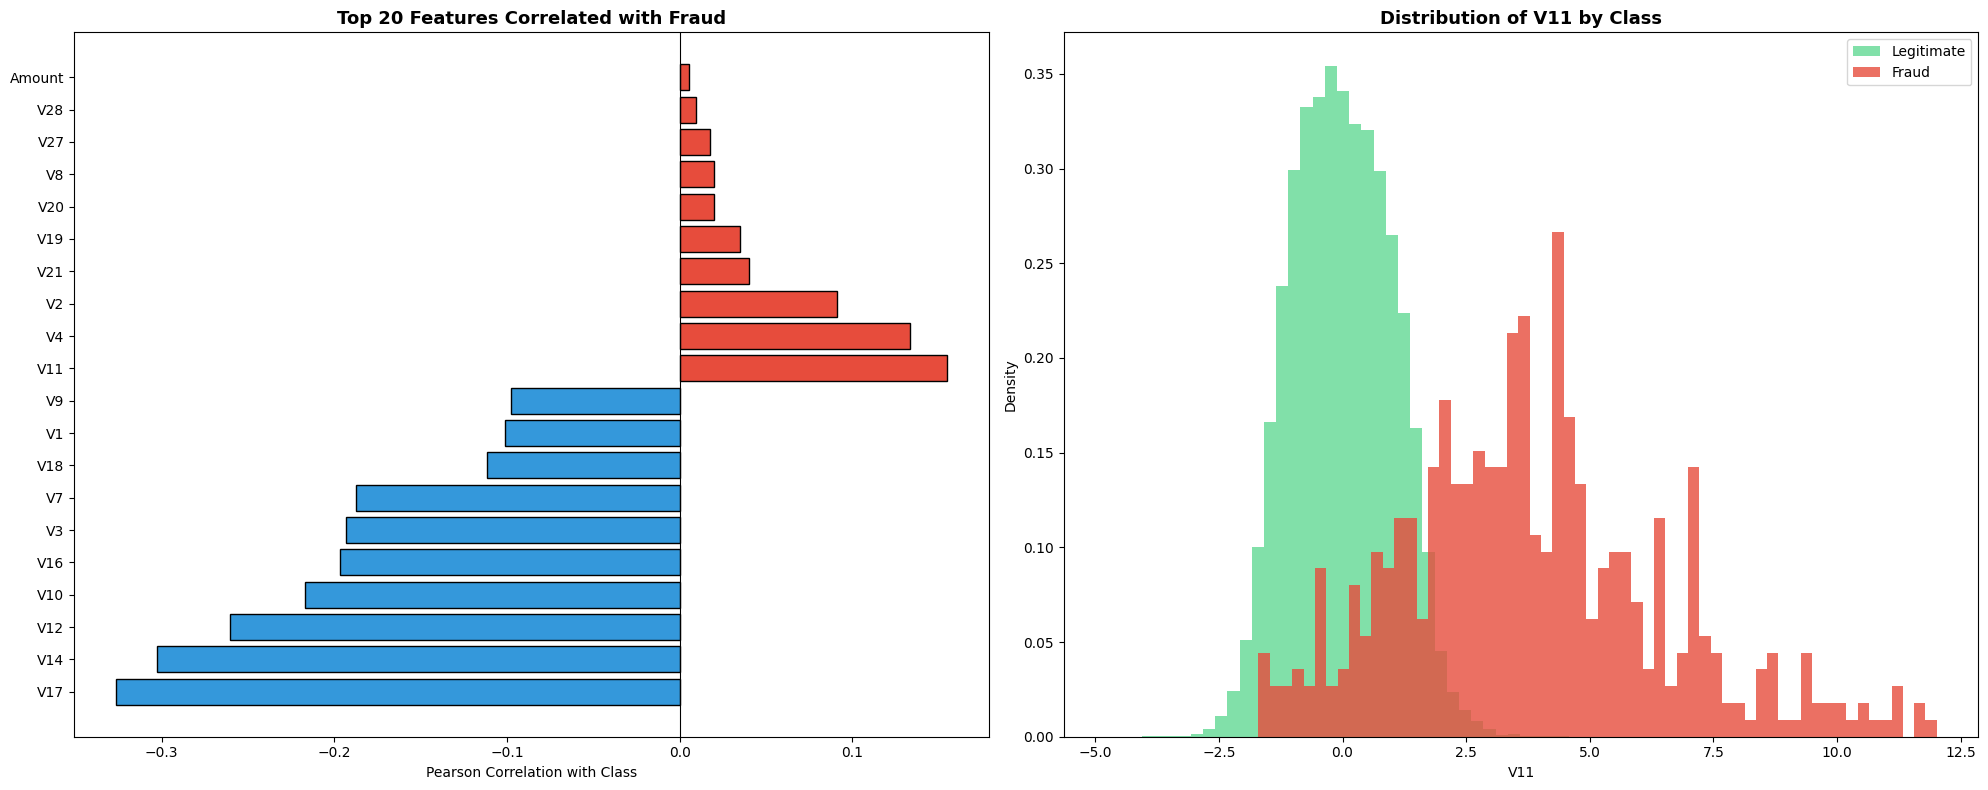

In [6]:
# Correlation heatmap for fraud transactions
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top correlated features with fraud
corr = df.corr()['Class'].drop('Class').sort_values()
top_pos = corr.nlargest(10)
top_neg = corr.nsmallest(10)
top_features = pd.concat([top_neg, top_pos])

colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_features.values]
axes[0].barh(top_features.index, top_features.values, color=colors, edgecolor='black')
axes[0].set_title('Top 20 Features Correlated with Fraud', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation with Class')
axes[0].axvline(0, color='black', linewidth=0.8)

# Distribution of top fraud-positive feature
top_feat = top_pos.index[0]
axes[1].hist(legit[top_feat], bins=60, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
axes[1].hist(fraud[top_feat], bins=60, alpha=0.8, label='Fraud', color='#e74c3c', density=True)
axes[1].set_title(f'Distribution of {top_feat} by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel(top_feat)
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ 4. Preprocessing

> **Strategy:**
> - Drop duplicate rows
> - Scale `Amount` and `Time` with **RobustScaler** (resistant to outliers)
> - V1–V28 are already PCA-transformed — no scaling needed
> - Handle imbalance with **SMOTE** on the training set only

In [7]:
# Step 1: Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df):,}")

# Step 2: Scale Amount and Time
scaler = RobustScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Step 3: Define features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Features             : {list(X.columns)}")

Removed 1081 duplicate rows. Remaining: 283,726

Feature matrix shape : (283726, 30)
Target shape         : (283726,)
Features             : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']


In [8]:
# Step 4: Stratified train/test split (preserves fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("SPLIT SUMMARY")
print(f"  Train set : {X_train.shape[0]:,} | Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"  Test set  : {X_test.shape[0]:,}  | Fraud: {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

SPLIT SUMMARY
  Train set : 226,980 | Fraud: 378 (0.167%)
  Test set  : 56,746  | Fraud: 95  (0.167%)


In [9]:
# Step 5: Apply SMOTE only on training data
# ⚠️ NEVER apply SMOTE before split — it causes data leakage!
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)  # minority becomes 50% of majority
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("AFTER SMOTE (training set only)")
print(f"  Total     : {len(X_train_res):,}")
print(f"  Legitimate: {(y_train_res==0).sum():,}")
print(f"  Fraud     : {(y_train_res==1).sum():,}")

AFTER SMOTE (training set only)
  Total     : 339,903
  Legitimate: 226,602
  Fraud     : 113,301


---
## 🤖 5. Model Training

We train **5 models** and compare:

| Model | Key Strength |
|-------|--------------|
| Logistic Regression | Fast baseline, interpretable |
| Random Forest | Handles non-linearity, robust |
| Gradient Boosting | Good on imbalanced data |
| XGBoost | State-of-art tabular, `scale_pos_weight` |
| LightGBM | Fast, memory efficient, best for large data |

> **Key metric:** We optimize for **AUPRC (Area Under Precision-Recall Curve)** — the gold standard for imbalanced classification, not accuracy.

In [10]:
# Class weight ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.1f}")

# Model definitions
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=4, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr', use_label_encoder=False,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        class_weight='balanced', random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    )
}

print(f"✅ {len(models)} models defined and ready to train.")

scale_pos_weight for XGBoost: 599.5
✅ 5 models defined and ready to train.


In [11]:
# Train all models and collect results
results = {}

for name, model in models.items():
    print(f"\n⏳ Training: {name}...")
    
    # Train on SMOTE-resampled data
    model.fit(X_train_res, y_train_res)
    
    # Predict on untouched test set
    y_pred       = model.predict(X_test)
    y_prob       = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    roc_auc  = roc_auc_score(y_test, y_prob)
    pr_auc   = average_precision_score(y_test, y_prob)
    f1       = f1_score(y_test, y_pred)
    prec     = precision_score(y_test, y_pred)
    rec      = recall_score(y_test, y_pred)
    
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'ROC-AUC'  : roc_auc,
        'PR-AUC'   : pr_auc,
        'F1'       : f1,
        'Precision': prec,
        'Recall'   : rec,
    }
    
    print(f"   ROC-AUC  : {roc_auc:.4f}")
    print(f"   PR-AUC   : {pr_auc:.4f}  ← Key metric")
    print(f"   F1 Score : {f1:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall   : {rec:.4f}")

print("\n✅ All models trained!")


⏳ Training: Logistic Regression...
   ROC-AUC  : 0.9598
   PR-AUC   : 0.6696  ← Key metric
   F1 Score : 0.1013
   Precision: 0.0538
   Recall   : 0.8737

⏳ Training: Random Forest...
   ROC-AUC  : 0.9639
   PR-AUC   : 0.8154  ← Key metric
   F1 Score : 0.8208
   Precision: 0.9103
   Recall   : 0.7474

⏳ Training: Gradient Boosting...
   ROC-AUC  : 0.9731
   PR-AUC   : 0.7056  ← Key metric
   F1 Score : 0.5000
   Precision: 0.3575
   Recall   : 0.8316

⏳ Training: XGBoost...
   ROC-AUC  : 0.9524
   PR-AUC   : 0.7457  ← Key metric
   F1 Score : 0.0639
   Precision: 0.0332
   Recall   : 0.8421

⏳ Training: LightGBM...
   ROC-AUC  : 0.9657
   PR-AUC   : 0.7872  ← Key metric
   F1 Score : 0.6553
   Precision: 0.5500
   Recall   : 0.8105

✅ All models trained!


---
## 📊 6. Evaluation & Comparison

In [12]:
# Summary table
summary = pd.DataFrame({
    name: {
        'ROC-AUC'  : res['ROC-AUC'],
        'PR-AUC'   : res['PR-AUC'],
        'F1'       : res['F1'],
        'Precision': res['Precision'],
        'Recall'   : res['Recall'],
    }
    for name, res in results.items()
}).T.sort_values('PR-AUC', ascending=False)

print("\n📋 MODEL COMPARISON (sorted by PR-AUC):")
print(summary.to_string(float_format='{:.4f}'.format))

best_model_name = summary.index[0]
print(f"\n🏆 Best Model: {best_model_name}")


📋 MODEL COMPARISON (sorted by PR-AUC):
                     ROC-AUC  PR-AUC     F1  Precision  Recall
Random Forest         0.9639  0.8154 0.8208     0.9103  0.7474
LightGBM              0.9657  0.7872 0.6553     0.5500  0.8105
XGBoost               0.9524  0.7457 0.0639     0.0332  0.8421
Gradient Boosting     0.9731  0.7056 0.5000     0.3575  0.8316
Logistic Regression   0.9598  0.6696 0.1013     0.0538  0.8737

🏆 Best Model: Random Forest


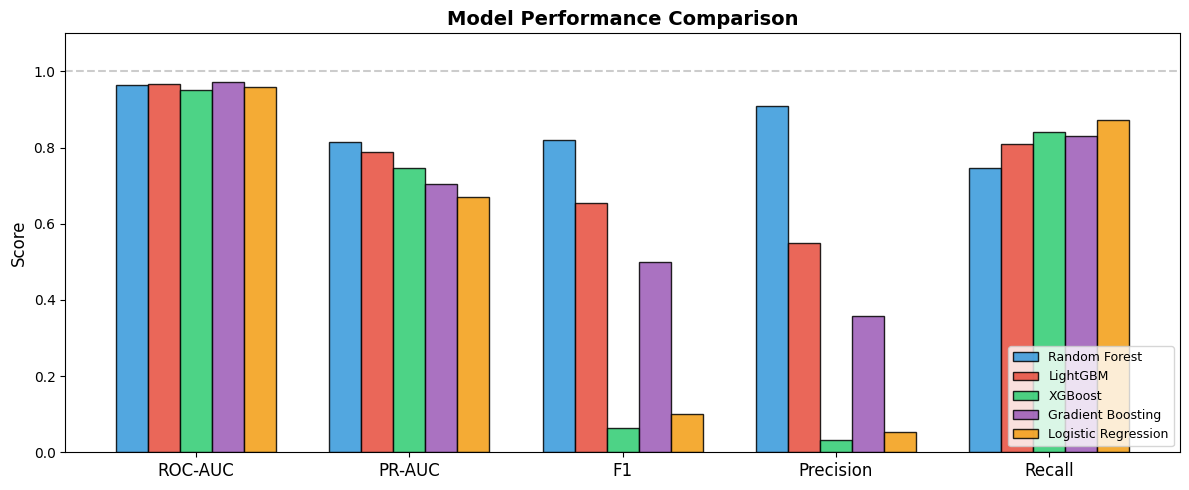

In [13]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 5))

metrics = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.15
colors_list = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for i, (name, row) in enumerate(summary.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name, color=colors_list[i], alpha=0.85, edgecolor='black')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

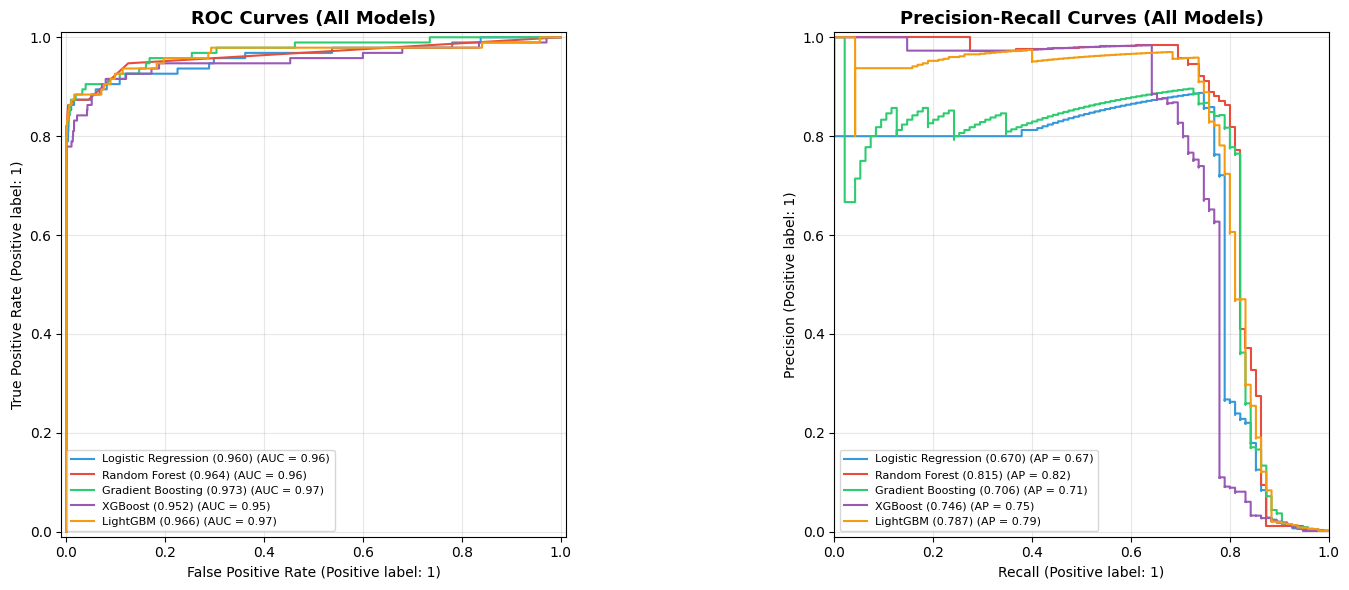

In [14]:
# ROC & Precision-Recall Curves for all models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, res) in enumerate(results.items()):
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} ({res['ROC-AUC']:.3f})",
        ax=axes[0], color=colors_list[i]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} ({res['PR-AUC']:.3f})",
        ax=axes[1], color=colors_list[i]
    )

axes[0].set_title('ROC Curves (All Models)', fontsize=13, fontweight='bold')
axes[1].set_title('Precision-Recall Curves (All Models)', fontsize=13, fontweight='bold')
axes[1].set_xlim([0, 1])

for ax in axes:
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

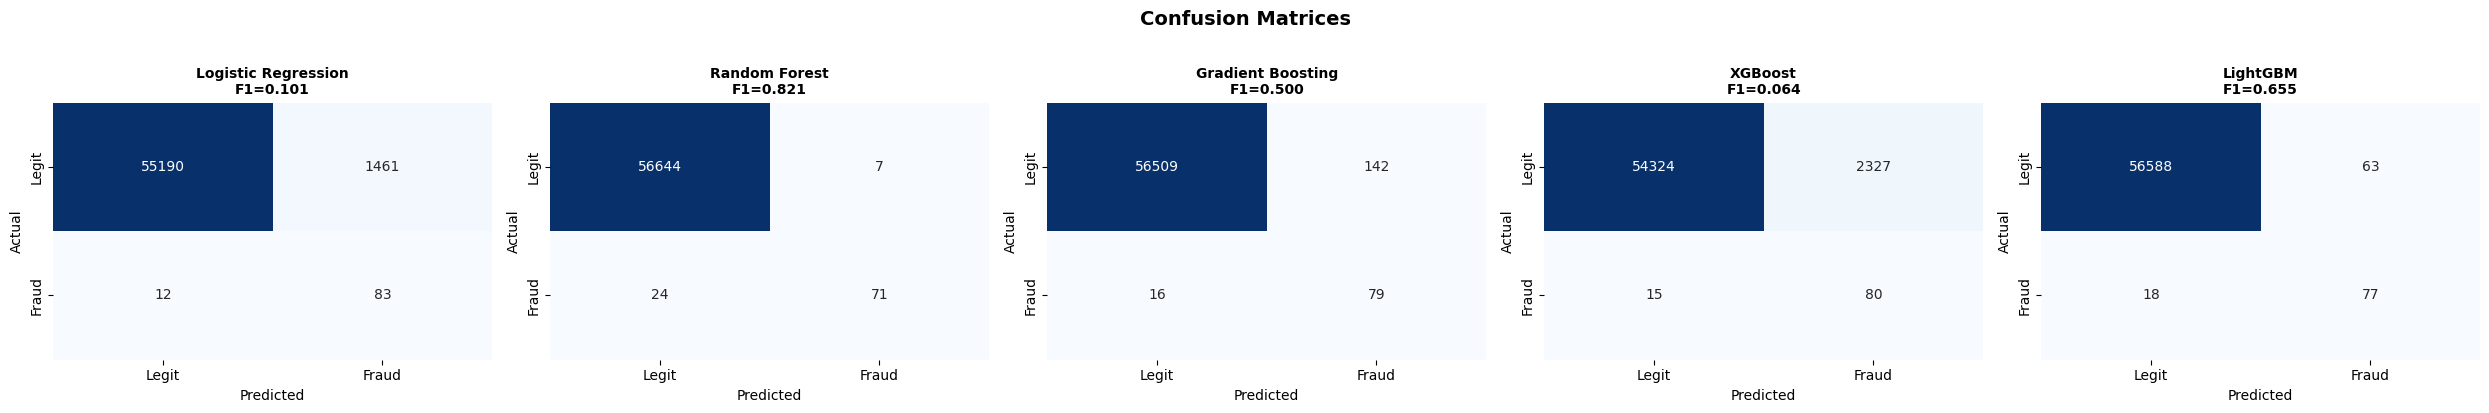

In [15]:
# Confusion matrices for all models
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud'],
        ax=ax, cbar=False
    )
    ax.set_title(f'{name}\nF1={res["F1"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Detailed report for best model
print(f"\n{'='*60}")
print(f"  DETAILED REPORT: {best_model_name}")
print(f"{'='*60}")
print(classification_report(
    y_test,
    results[best_model_name]['y_pred'],
    target_names=['Legitimate', 'Fraud']
))


  DETAILED REPORT: Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.91      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



---
## 🔧 7. Threshold Tuning

Default threshold = 0.5 is not optimal for fraud detection.
We tune the decision threshold to maximize **F1** or prioritize **Recall** (catch more fraud).

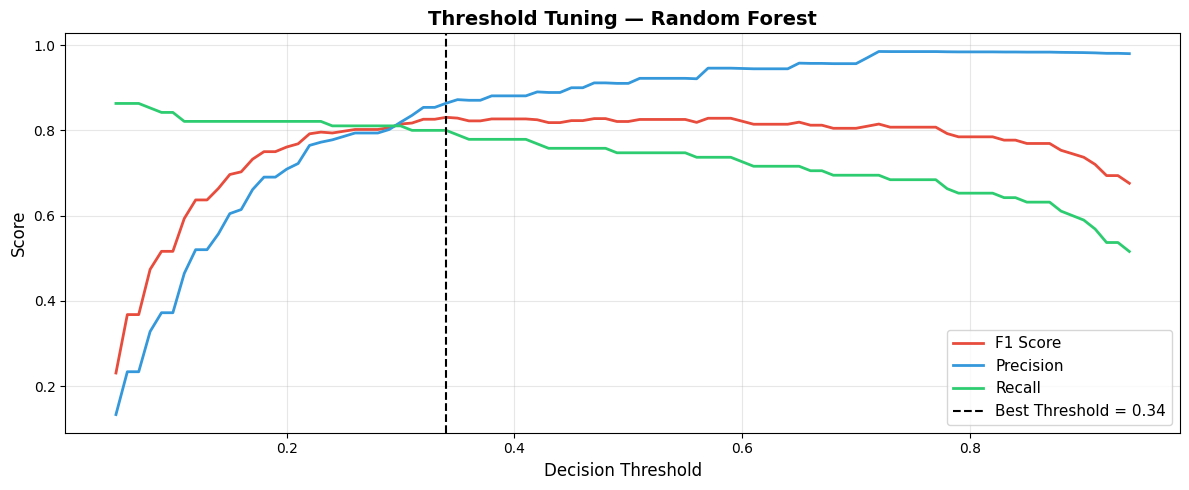


🎯 Optimal Threshold: 0.34
   F1       : 0.8306
   Precision: 0.8636
   Recall   : 0.8000


In [17]:
best_probs = results[best_model_name]['y_prob']
thresholds = np.arange(0.05, 0.95, 0.01)

f1s, precs, recs = [], [], []
for t in thresholds:
    preds = (best_probs >= t).astype(int)
    f1s.append(f1_score(y_test, preds, zero_division=0))
    precs.append(precision_score(y_test, preds, zero_division=0))
    recs.append(recall_score(y_test, preds, zero_division=0))

best_thresh_idx = np.argmax(f1s)
best_thresh     = thresholds[best_thresh_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, f1s,   label='F1 Score',  color='#e74c3c', linewidth=2)
ax.plot(thresholds, precs, label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds, recs,  label='Recall',    color='#2ecc71', linewidth=2)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Best Threshold = {best_thresh:.2f}')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Threshold Tuning — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🎯 Optimal Threshold: {best_thresh:.2f}")
print(f"   F1       : {f1s[best_thresh_idx]:.4f}")
print(f"   Precision: {precs[best_thresh_idx]:.4f}")
print(f"   Recall   : {recs[best_thresh_idx]:.4f}")

In [18]:
# Apply tuned threshold
y_pred_tuned = (best_probs >= best_thresh).astype(int)

print(f"Classification report with tuned threshold ({best_thresh:.2f}):")
print(classification_report(y_test, y_pred_tuned, target_names=['Legitimate', 'Fraud']))

Classification report with tuned threshold (0.34):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.86      0.80      0.83        95

    accuracy                           1.00     56746
   macro avg       0.93      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746



---
## 🌟 8. Feature Importance

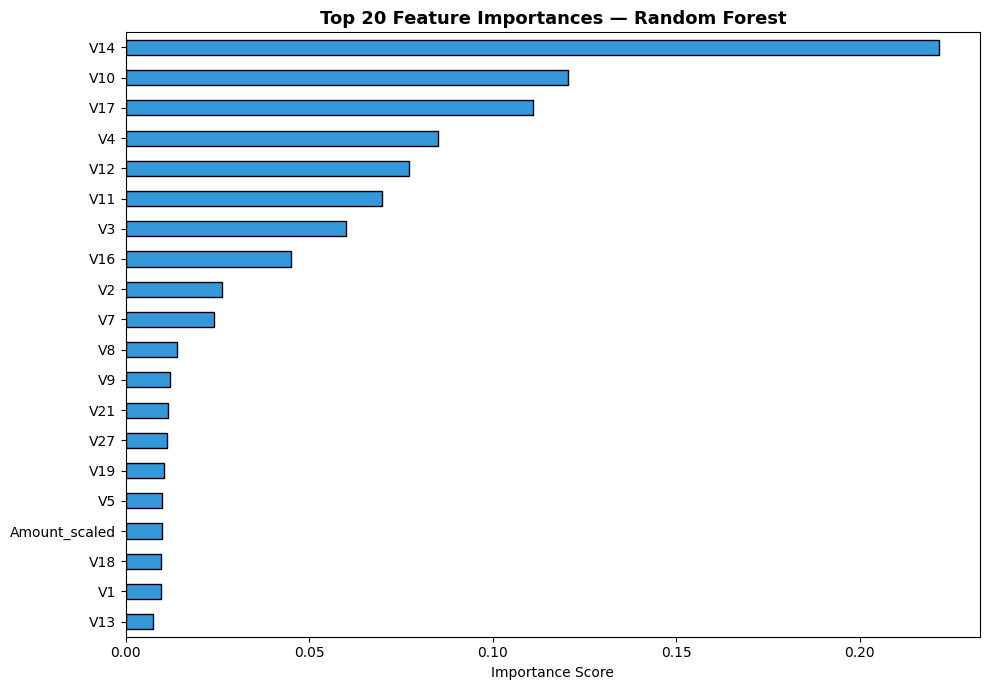

In [19]:
# Feature importance for tree-based best model
best_model = results[best_model_name]['model']

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top20 = importances.nlargest(20).sort_values()
    
    fig, ax = plt.subplots(figsize=(10, 7))
    top20.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Feature importance not available for this model type.")

---
## ✅ 9. Cross-Validation (Best Model)

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate

print(f"Running 5-fold Stratified CV on {best_model_name}...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    best_model,
    X_train_res, y_train_res,
    cv=cv,
    scoring=['roc_auc', 'average_precision', 'f1'],
    n_jobs=-1,
    return_train_score=False
)

print(f"\n5-Fold CV Results ({best_model_name}):")
print(f"  ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"  PR-AUC   : {cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}")
print(f"  F1       : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

Running 5-fold Stratified CV on Random Forest...

5-Fold CV Results (Random Forest):
  ROC-AUC  : 1.0000 ± 0.0000
  PR-AUC   : 1.0000 ± 0.0000
  F1       : 0.9998 ± 0.0001


---
## 💾 10. Save the Best Model

In [21]:
import joblib

model_path  = f'fraud_model_{best_model_name.lower().replace(" ", "_")}.pkl'
scaler_path = 'robust_scaler.pkl'

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"✅ Model saved  : {model_path}")
print(f"✅ Scaler saved : {scaler_path}")

✅ Model saved  : fraud_model_random_forest.pkl
✅ Scaler saved : robust_scaler.pkl


---
## 🔮 11. Inference on New Transactions

In [22]:
def predict_fraud(transaction_df, model, threshold=None):
    """
    Predict fraud for new transactions.
    
    Parameters:
    -----------
    transaction_df : pd.DataFrame with columns V1-V28, Amount, Time
    model          : trained model
    threshold      : custom decision threshold (default = best_thresh)
    
    Returns:
    --------
    DataFrame with predictions and fraud probabilities
    """
    if threshold is None:
        threshold = best_thresh
    
    df_new = transaction_df.copy()
    df_new['Amount_scaled'] = scaler.transform(df_new[['Amount']])
    df_new['Time_scaled']   = scaler.transform(df_new[['Time']])
    df_new.drop(['Amount', 'Time'], axis=1, inplace=True)
    
    probs   = model.predict_proba(df_new)[:, 1]
    preds   = (probs >= threshold).astype(int)
    labels  = ['🚨 FRAUD' if p == 1 else '✅ LEGIT' for p in preds]
    
    return pd.DataFrame({
        'Fraud_Probability': probs,
        'Prediction': preds,
        'Label': labels
    })


# Demo: sample 5 random test transactions
sample = X_test.copy()
sample['Amount'] = df.loc[X_test.index, 'Amount_scaled']  # using scaled as proxy
sample['Time']   = df.loc[X_test.index, 'Time_scaled']

# Quick demo using raw X_test (already preprocessed)

demo_probs  = results[best_model_name]['y_prob'][:5]
demo_preds  = (demo_probs >= best_thresh).astype(int)
demo_actual = y_test.values[:5]

demo_df = pd.DataFrame({
    'Fraud_Probability': demo_probs,
    'Predicted': ['🚨 FRAUD' if p else '✅ LEGIT' for p in demo_preds],
    'Actual':    ['🚨 FRAUD' if a else '✅ LEGIT' for a in demo_actual]
})

print("Sample Inference Results (first 5 test transactions):")
print(demo_df.to_string(index=False))

Sample Inference Results (first 5 test transactions):
 Fraud_Probability Predicted  Actual
              0.00   ✅ LEGIT ✅ LEGIT
              0.00   ✅ LEGIT ✅ LEGIT
              0.01   ✅ LEGIT ✅ LEGIT
              0.00   ✅ LEGIT ✅ LEGIT
              0.00   ✅ LEGIT ✅ LEGIT


---
## 📝 12. Summary & Recommendations

### Key Takeaways

| Aspect | Decision |
|--------|----------|
| **Imbalance handling** | SMOTE on training set only (avoid leakage) |
| **Scaling** | RobustScaler for Amount & Time (outlier-resistant) |
| **Key metric** | PR-AUC, not accuracy or ROC-AUC alone |
| **Threshold** | Tuned using F1 curve — not default 0.5 |
| **Cross-validation** | StratifiedKFold preserves class ratio |

### Next Steps to Improve Further
1. **Hyperparameter Tuning** — Use `Optuna` or `GridSearchCV` on XGBoost/LightGBM
2. **Cost-sensitive learning** — Assign higher misclassification cost to fraud
3. **Ensemble stacking** — Stack multiple models with a meta-learner
4. **Anomaly detection** — Try Isolation Forest or AutoEncoders as unsupervised complement
5. **Real-time deployment** — Wrap model in FastAPI for REST inference